In [1]:
import os
import pandas as pd

# 1. See where Jupyter is currently looking
print("Current Working Directory:", os.getcwd())

# 2. Try loading using the direct Downloads path if it's in your Downloads folder
# (Change 'USER' to your actual Windows username if it differs, or use the exact path from your screenshot)
file_path = r'C:\Users\USER\Downloads\Coffee Shop Sales.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("File loaded successfully from Downloads! Shape:", df.shape)
else:
    print("File not found at that path. Let's check files in the current folder:")
    print(os.listdir('.'))

Current Working Directory: C:\Users\USER
File loaded successfully from Downloads! Shape: (149116, 11)


In [2]:
# Create a working copy for cleaning
df_clean = df.copy()

# 1. Convert Date and Time columns to proper datetime objects
df_clean['transaction_date'] = pd.to_datetime(df_clean['transaction_date'], format='%m/%d/%y')
df_clean['transaction_time'] = pd.to_datetime(df_clean['transaction_time'], format='%H:%M:%S', errors='coerce').dt.time

# 2. Feature Engineering (Adding columns for analysis)
df_clean['total_sales'] = df_clean['transaction_qty'] * df_clean['unit_price']
df_clean['month'] = df_clean['transaction_date'].dt.month_name()
df_clean['day_of_week'] = df_clean['transaction_date'].dt.day_name()
df_clean['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S', errors='coerce').dt.hour

# 3. Clean text strings (remove accidental leading/trailing whitespace)
text_columns = ['store_location', 'product_category', 'product_type', 'product_detail']
for col in text_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 4. Export the cleaned dataset to your working folder
output_filename = 'coffee_shop_sales_cleaned.csv'
df_clean.to_csv(output_filename, index=False)

print(f"Cleaning complete! Saved successfully as '{output_filename}'.")
print(f"Final shape: {df_clean.shape}")

Cleaning complete! Saved successfully as 'coffee_shop_sales_cleaned.csv'.
Final shape: (149116, 15)


In [3]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv('coffee_shop_sales_cleaned.csv')

# Display column names and first 5 rows
print("Columns in our dataset:")
print(df.columns.tolist())

display(df.head())

Columns in our dataset:
['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'total_sales', 'month', 'day_of_week', 'hour']


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,total_sales,month,day_of_week,hour
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,January,Sunday,7
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,January,Sunday,7
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,January,Sunday,7
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7


In [4]:
import pandas as pd

# 1. Load your cleaned dataset
df = pd.read_csv('coffee_shop_sales_cleaned.csv')

# 2. High-Level Summary Statistics
print("=== HIGH-LEVEL METRICS (Jan - Jun 2023) ===")
total_revenue = df['total_sales'].sum()
total_transactions = df['transaction_id'].count()
total_items_sold = df['transaction_qty'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Items Sold: {total_items_sold:,}")

# 3. Revenue by Store Location
print("\n=== REVENUE BY STORE LOCATION ===")
store_summary = df.groupby('store_location').agg(
    total_revenue=('total_sales', 'sum'),
    total_orders=('transaction_id', 'count'),
    avg_order_value=('total_sales', 'mean')
).reset_index().sort_values(by='total_revenue', ascending=False)
display(store_summary)

# 4. Top Product Categories by Revenue
print("\n=== TOP PRODUCT CATEGORIES ===")
category_summary = df.groupby('product_category').agg(
    total_revenue=('total_sales', 'sum'),
    items_sold=('transaction_qty', 'sum')
).reset_index().sort_values(by='total_revenue', ascending=False)
display(category_summary)

# 5. Peak Sales Hours
print("\n=== PEAK SALES BY HOUR ===")
hourly_summary = df.groupby('hour')['total_sales'].sum().reset_index()
peak_row = hourly_summary.loc[hourly_summary['total_sales'].idxmax()]
print(f"The highest revenue-generating hour of the day is {int(peak_row['hour'])}:00 with ${peak_row['total_sales']:,.2f} in sales.")

=== HIGH-LEVEL METRICS (Jan - Jun 2023) ===
Total Revenue: $698,812.33
Total Transactions: 149,116
Total Items Sold: 214,470

=== REVENUE BY STORE LOCATION ===


,store_location,total_revenue,total_orders,avg_order_value
1,Hell's Kitchen,236511.17,50735,4.661696
0,Astoria,232243.91,50599,4.589891
2,Lower Manhattan,230057.25,47782,4.814726



=== TOP PRODUCT CATEGORIES ===


,product_category,total_revenue,items_sold
2,Coffee,269952.45,89250
8,Tea,196405.95,69737
0,Bakery,82315.64,23214
4,Drinking Chocolate,72416.00,17457
3,Coffee beans,40085.25,1828
1,Branded,13607.00,776
6,Loose Tea,11213.60,1210
5,Flavours,8408.80,10511
7,Packaged Chocolate,4407.64,487



=== PEAK SALES BY HOUR ===
The highest revenue-generating hour of the day is 10:00 with $88,673.39 in sales.


In [5]:
"""
Coffee shop sales: answers to the five business questions.

  1. Which location is busiest, and at what time?
  2. Each location with its top-selling product
  3. Which location generates more revenue?
  4. Which coffee is most consumed across all locations?
  5. Which product is bought less but earns more than a heavily consumed one?

Run it top to bottom. In Jupyter:  %run coffee_business_questions.py
The "# %%" lines also make it work as cells in VS Code / Spyder.
"""

# %% Setup ---------------------------------------------------------------
import os
from pathlib import Path

import pandas as pd

# Edit this if your file is elsewhere (or set the COFFEE_CSV environment variable).
RAW_PATH = Path(os.environ.get("COFFEE_CSV", r"C:\Users\USER\Downloads\Coffee Shop Sales.csv"))

# Decision you control: count Small / Regular / Large as ONE product (True)
# or as separate products (False)? It changes the answers to Q2, Q4 and Q5.
MERGE_SIZES = True

# Only fixes I'm confident are typos.
TYPO_FIXES = {"Jamacian Coffee River": "Jamaican Coffee River", "Carmel syrup": "Caramel syrup"}


def find_file():
    """Use RAW_PATH if it exists, otherwise look for a coffee CSV in the usual Downloads folders."""
    if RAW_PATH.exists():
        return RAW_PATH
    home = Path.home()
    for folder in (home / "Downloads", home / "OneDrive" / "Downloads"):
        if folder.exists():
            for f in folder.iterdir():
                if "coffee" in f.name.lower() and f.suffix.lower() == ".csv":
                    return f
    raise FileNotFoundError(f"Could not find the coffee CSV. Set RAW_PATH at the top of this script. Tried: {RAW_PATH}")


def show(title, frame):
    print(f"\n{title}")
    print(frame.to_string(index=False))


# %% Load and clean ------------------------------------------------------
path = find_file()
df = pd.read_csv(path)
print("Loaded:", path, df.shape)

# Text: strip stray whitespace (1,952 product_detail values had it), fix typos
for col in ["store_location", "product_category", "product_type", "product_detail"]:
    df[col] = df[col].str.strip()
df["product_detail"] = df["product_detail"].replace(TYPO_FIXES)

# Dates and times. No errors="coerce": bad values should fail loudly.
df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="%m/%d/%y")
df["hour"] = pd.to_datetime(df["transaction_time"], format="%H:%M:%S").dt.hour

# Revenue
df["revenue"] = (df["transaction_qty"] * df["unit_price"]).round(2)

# Split the size (Sm / Rg / Lg) out of product_detail
size_pattern = r"\s+(Sm|Rg|Lg)$"
df["product_base"] = df["product_detail"].str.replace(size_pattern, "", regex=True)
df["product"] = df["product_base"] if MERGE_SIZES else df["product_detail"]

assert df.isna().sum().sum() == 0, "unexpected nulls"
assert df["transaction_id"].is_unique, "duplicate transaction ids"
print(f"Cleaned. Total revenue: ${df['revenue'].sum():,.2f} | sizes merged: {MERGE_SIZES}")

# %% Q1: busiest location and time ---------------------------------------
print("\n" + "=" * 70 + "\nQ1. WHICH LOCATION IS BUSIEST, AND AT WHAT TIME?\n" + "=" * 70)

tx_by_store = df.groupby("store_location").size().sort_values(ascending=False)
busiest = tx_by_store.index[0]
print(f"Busiest location by transactions: {busiest} ({tx_by_store.iloc[0]:,})")
if (tx_by_store.iloc[0] - tx_by_store.iloc[1]) / tx_by_store.iloc[1] < 0.02:
    print(f"  Note: {tx_by_store.index[1]} is within 2% ({tx_by_store.iloc[1]:,}), so they are effectively tied.")

tx_hour_store = df.groupby(["store_location", "hour"]).size().rename("transactions").reset_index()
peak = tx_hour_store.loc[tx_hour_store.groupby("store_location")["transactions"].idxmax()]
print("\nPeak hour per location:")
for _, r in peak.iterrows():
    print(f"  {r['store_location']}: {int(r['hour'])}:00 ({r['transactions']:,} transactions)")

# Busiest 4-hour window by revenue, overall
rev_hour = df.groupby("hour")["revenue"].sum()
window = rev_hour.rolling(4).sum().dropna()
end_hour = window.idxmax()
start_hour = end_hour - 3
share = window.max() / rev_hour.sum() * 100
print(f"\nBusiest 4-hour window: {start_hour}:00 to {end_hour + 1}:00, "
      f"{share:.1f}% of all revenue")

top_hours = (
    tx_hour_store.sort_values(["store_location", "transactions"], ascending=[True, False])
    .groupby("store_location").head(3)
)
show("Top 3 hours per location (transactions):", top_hours)

daily = df.groupby(df["transaction_date"].dt.dayofweek >= 5).apply(
    lambda x: x["revenue"].sum() / x["transaction_date"].nunique(), include_groups=False
)
print(f"\nAverage daily revenue: weekday ${daily[False]:,.0f} | weekend ${daily[True]:,.0f}")

# %% Q2: top product per location ----------------------------------------
print("\n" + "=" * 70 + "\nQ2. EACH LOCATION WITH ITS TOP-SELLING PRODUCT\n" + "=" * 70)
print(f"(sizes {'merged into one product' if MERGE_SIZES else 'counted as separate products'})")

by_store_product = (
    df.groupby(["store_location", "product", "product_category"])
    .agg(units=("transaction_qty", "sum"), revenue=("revenue", "sum"))
    .reset_index()
)

for metric, label in [("units", "UNITS SOLD"), ("revenue", "REVENUE")]:
    idx = by_store_product.groupby("store_location")[metric].idxmax()
    result = by_store_product.loc[idx].sort_values(metric, ascending=False)
    show(f"Top product per location by {label}:", result)

# %% Q3: revenue by location ----------------------------------------------
print("\n" + "=" * 70 + "\nQ3. WHICH LOCATION GENERATES MORE REVENUE?\n" + "=" * 70)

store = (
    df.groupby("store_location")
    .agg(revenue=("revenue", "sum"), transactions=("transaction_id", "count"))
    .assign(avg_sale=lambda x: (x["revenue"] / x["transactions"]).round(2))
    .sort_values("revenue", ascending=False)
    .reset_index()
)
store["revenue"] = store["revenue"].round(2)
show("Revenue by location:", store)

gap = (store["revenue"].iloc[0] - store["revenue"].iloc[-1]) / store["revenue"].iloc[-1] * 100
print(f"\n{store['store_location'].iloc[0]} earns the most. Gap between first and last: {gap:.1f}%.")
print(f"Highest average sale: {store.sort_values('avg_sale').iloc[-1]['store_location']} "
      f"(${store['avg_sale'].max():.2f})")

# %% Q4: most consumed coffee across all locations ------------------------
print("\n" + "=" * 70 + "\nQ4. WHICH COFFEE IS MOST CONSUMED ACROSS ALL LOCATIONS?\n" + "=" * 70)

coffee = df[df["product_category"] == "Coffee"]
units = coffee.pivot_table(index="product", columns="store_location",
                           values="transaction_qty", aggfunc="sum")
units["all_stores"] = units.sum(axis=1)
units = units.sort_values("all_stores", ascending=False)
show("Top 8 coffee products by units (per store and overall):", units.head(8).reset_index())

first, second = units["all_stores"].iloc[0], units["all_stores"].iloc[1]
print(f"\nTop overall: {units.index[0]} ({int(first):,} units).")
print(f"Gap to #2 ({units.index[1]}): {(first - second) / second * 100:.1f}%"
      f"{'  -> effectively a tie' if (first - second) / second < 0.05 else ''}")

stores = [c for c in units.columns if c != "all_stores"]
top5_each = [set(units[s].sort_values(ascending=False).head(5).index) for s in stores]
in_every_top5 = sorted(set.intersection(*top5_each))
print(f"Products in the top 5 of EVERY location: {', '.join(in_every_top5)}")

# %% Q5: low volume, high revenue -----------------------------------------
print("\n" + "=" * 70 + "\nQ5. LESS BOUGHT, BUT EARNS MORE THAN A HEAVILY CONSUMED PRODUCT\n" + "=" * 70)

prod = (
    df.groupby(["product", "product_category"])
    .agg(units=("transaction_qty", "sum"), revenue=("revenue", "sum"))
    .reset_index()
)
prod["revenue_per_unit"] = (prod["revenue"] / prod["units"]).round(2)

low_volume = prod[prod["units"] <= prod["units"].median()]

# For each low-volume product: how many products with MORE units does it out-earn?
def beats(row):
    return int(((prod["units"] > row["units"]) & (prod["revenue"] < row["revenue"])).sum())

low_volume = low_volume.assign(products_out_earned=low_volume.apply(beats, axis=1))
show("Low-volume products ranked by how many higher-volume products they out-earn:",
     low_volume.sort_values(["products_out_earned", "revenue"], ascending=False).head(6))

star = low_volume.sort_values(["products_out_earned", "revenue"], ascending=False).iloc[0]
beaten = prod[(prod["units"] > star["units"]) & (prod["revenue"] < star["revenue"])].sort_values("units", ascending=False)
print(f"\n{star['product']} sold only {int(star['units']):,} units but earned ${star['revenue']:,.2f}.")
show(f"Products with more units that {star['product']} out-earns:", beaten.head(8))

top10_units = prod.sort_values("units", ascending=False).head(10)
print(f"\nReality check: the 10 best-selling products earn ${top10_units['revenue'].min():,.0f} to "
      f"${top10_units['revenue'].max():,.0f} each; the best low-volume product earns "
      f"${low_volume['revenue'].max():,.0f}. So niche items beat mid-volume products, not the top sellers.")

cat = (
    df.groupby("product_category")
    .agg(units=("transaction_qty", "sum"), revenue=("revenue", "sum"))
    .assign(revenue_per_unit=lambda x: (x["revenue"] / x["units"]).round(2))
    .sort_values("revenue_per_unit", ascending=False).reset_index()
)
show("Revenue per unit by category:", cat)

Loaded: C:\Users\USER\Downloads\Coffee Shop Sales.csv (149116, 11)
Cleaned. Total revenue: $698,812.33 | sizes merged: True

Q1. WHICH LOCATION IS BUSIEST, AND AT WHAT TIME?
Busiest location by transactions: Hell's Kitchen (50,735)
  Note: Astoria is within 2% (50,599), so they are effectively tied.

Peak hour per location:
  Astoria: 10:00 (5,291 transactions)
  Hell's Kitchen: 10:00 (6,957 transactions)
  Lower Manhattan: 10:00 (6,297 transactions)

Busiest 4-hour window: 7:00 to 11:00, 45.8% of all revenue

Top 3 hours per location (transactions):
 store_location  hour  transactions
        Astoria    10          5291
        Astoria     9          5083
        Astoria     8          4966
 Hell's Kitchen    10          6957
 Hell's Kitchen     8          6909
 Hell's Kitchen     9          6767
Lower Manhattan    10          6297
Lower Manhattan     9          5914
Lower Manhattan     7          5792

Average daily revenue: weekday $3,874 | weekend $3,828

Q2. EACH LOCATION WITH ITS

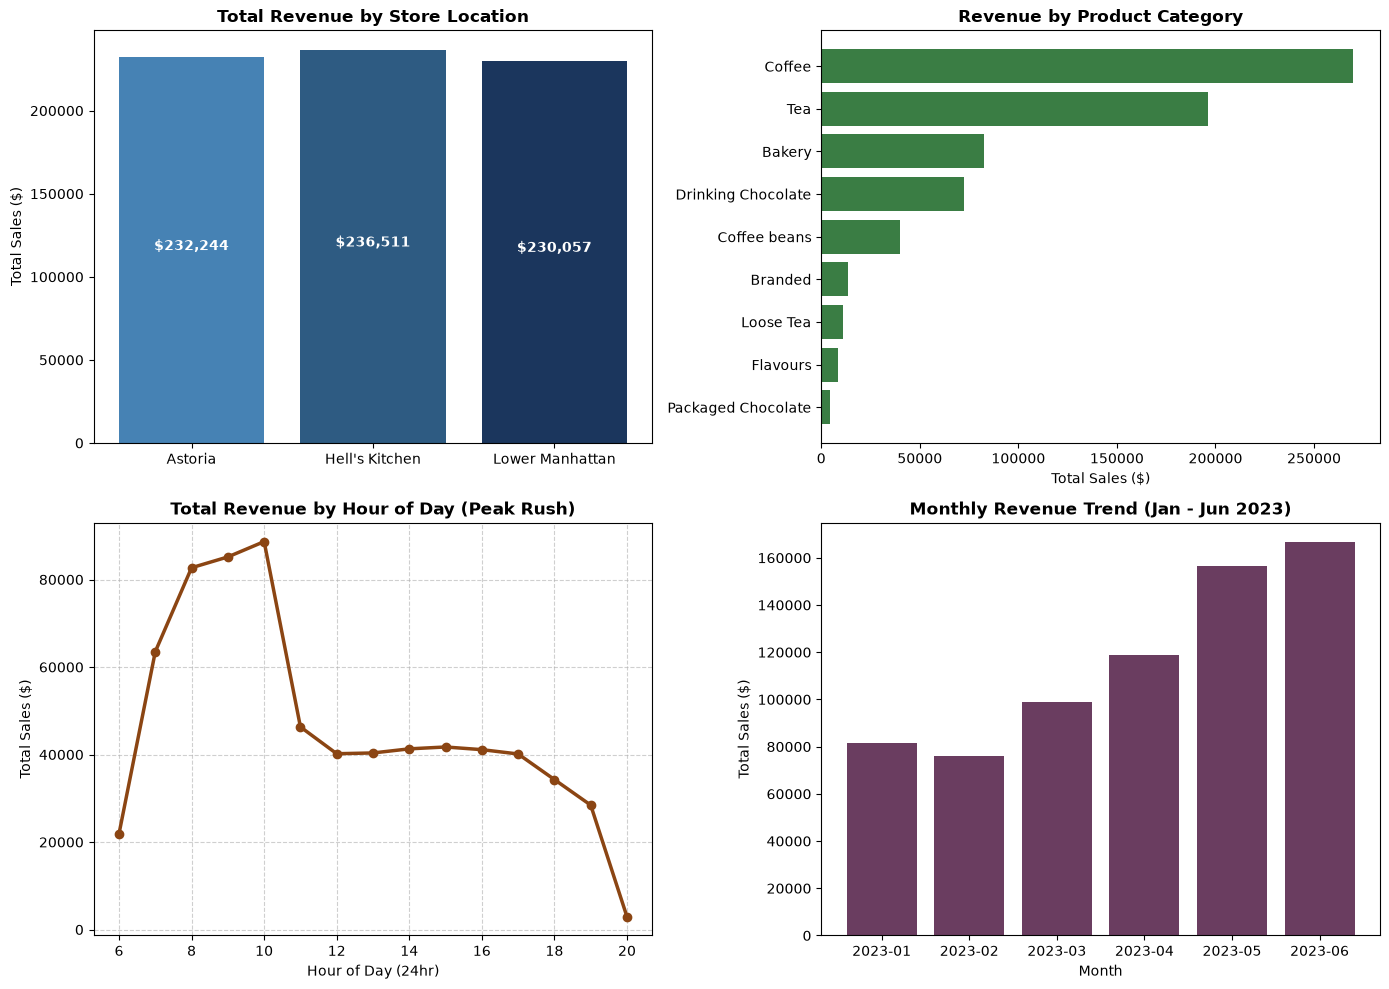

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your cleaned dataset
df = pd.read_csv('coffee_shop_sales_cleaned.csv')

# Set up a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Chart 1: Revenue by Store Location (Bar Chart) ---
store_rev = df.groupby('store_location')['total_sales'].sum()
axes[0, 0].bar(store_rev.index, store_rev.values, color=['#4682B4', '#2E5B82', '#1B365D'])
axes[0, 0].set_title('Total Revenue by Store Location', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Total Sales ($)')
for i, v in enumerate(store_rev.values):
    axes[0, 0].text(i, v / 2, f"${v:,.0f}", ha='center', color='white', fontweight='bold')

# --- Chart 2: Revenue by Product Category (Horizontal Bar Chart) ---
cat_rev = df.groupby('product_category')['total_sales'].sum().sort_values(ascending=True)
axes[0, 1].barh(cat_rev.index, cat_rev.values, color='#3A7D44')
axes[0, 1].set_title('Revenue by Product Category', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Sales ($)')

# --- Chart 3: Peak Sales by Hour (Line Chart) ---
hourly = df.groupby('hour')['total_sales'].sum()
axes[1, 0].plot(hourly.index, hourly.values, marker='o', color='#8B4513', linewidth=2.5)
axes[1, 0].set_title('Total Revenue by Hour of Day (Peak Rush)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hour of Day (24hr)')
axes[1, 0].set_ylabel('Total Sales ($)')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# --- Chart 4: Monthly Revenue Trend (Bar Chart) ---
df['year_month'] = pd.to_datetime(df['transaction_date']).dt.to_period('M').astype(str)
monthly = df.groupby('year_month')['total_sales'].sum()
axes[1, 1].bar(monthly.index, monthly.values, color='#6A3D60')
axes[1, 1].set_title('Monthly Revenue Trend (Jan - Jun 2023)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

saved coffee_combined.png


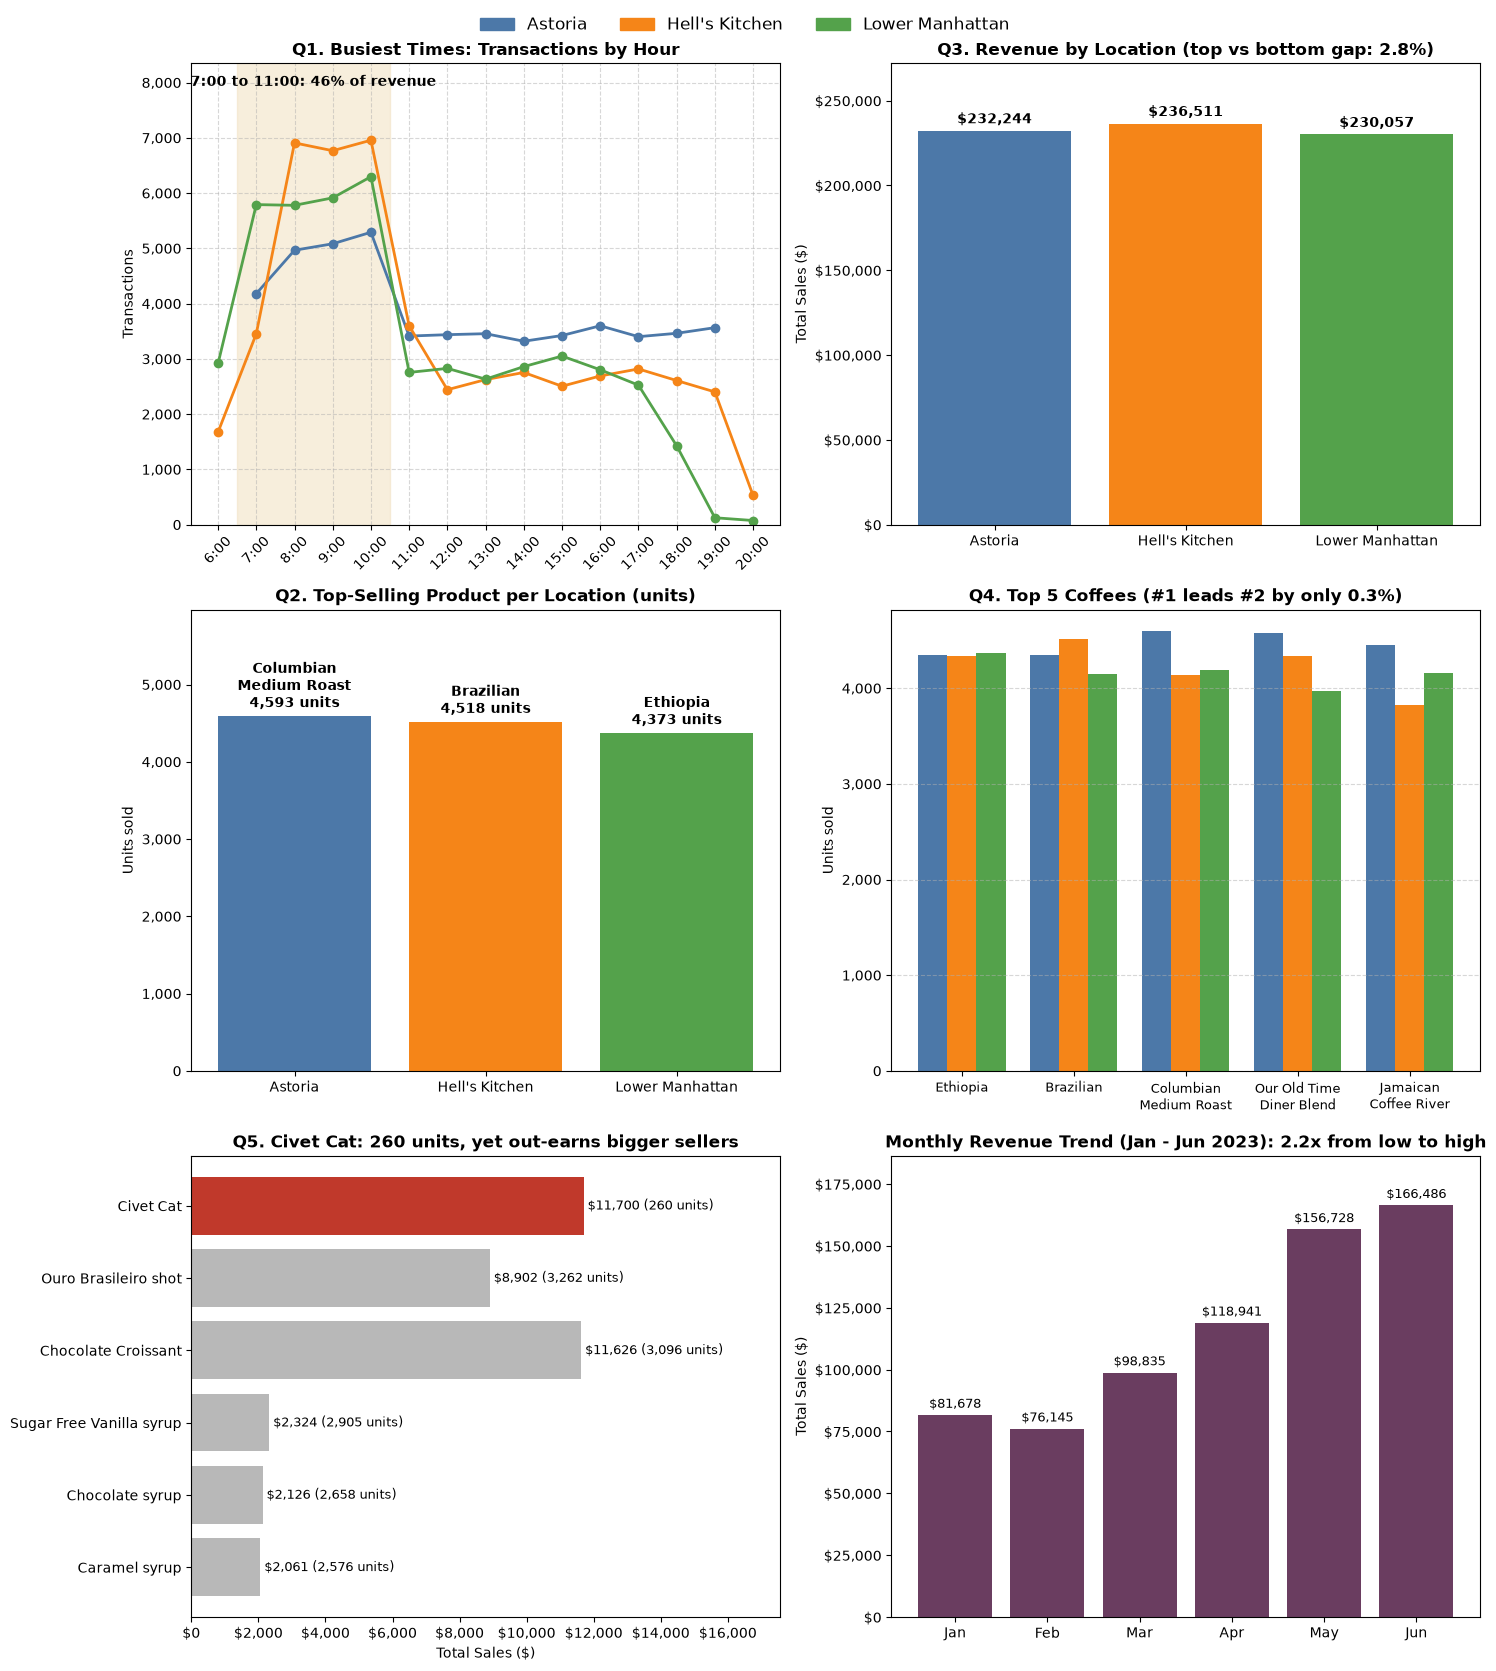

In [7]:
"""
Coffee shop sales: all charts combined in ONE figure with plt.subplots (3 rows x 2 columns),
the same approach as your 2x2 chart.

  [0,0] Q1  Busiest times (revenue by hour is in your old chart; here it is transactions by hour per store)
  [0,1] Q3  Revenue by location
  [1,0] Q2  Top product per location
  [1,1] Q4  Top 5 coffees, all locations
  [2,0] Q5  Low volume, high revenue
  [2,1]     Monthly revenue growth

In Jupyter:  %run coffee_combined.py
"""
import os
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
from matplotlib.patches import Patch

RAW_PATH = Path(os.environ.get("COFFEE_CSV", r"C:\Users\USER\Downloads\Coffee Shop Sales.csv"))
MERGE_SIZES = True          # count Small / Regular / Large as one product
TYPO_FIXES = {"Jamacian Coffee River": "Jamaican Coffee River", "Carmel syrup": "Caramel syrup"}
STORES = ["Astoria", "Hell's Kitchen", "Lower Manhattan"]
COLORS = {"Astoria": "#4C78A8", "Hell's Kitchen": "#F58518", "Lower Manhattan": "#54A24B"}

money = mtick.FuncFormatter(lambda v, _: f"${v:,.0f}")
thousands = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}")


def find_file():
    if RAW_PATH.exists():
        return RAW_PATH
    home = Path.home()
    for folder in (home / "Downloads", home / "OneDrive" / "Downloads"):
        if folder.exists():
            for f in folder.iterdir():
                if "coffee" in f.name.lower() and f.suffix.lower() == ".csv":
                    return f
    raise FileNotFoundError(f"Could not find the coffee CSV. Set RAW_PATH at the top. Tried: {RAW_PATH}")


# ----------------------------------------------------------- load and clean
df = pd.read_csv(find_file())
for col in ["store_location", "product_category", "product_type", "product_detail"]:
    df[col] = df[col].str.strip()
df["product_detail"] = df["product_detail"].replace(TYPO_FIXES)
df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="%m/%d/%y")
df["hour"] = pd.to_datetime(df["transaction_time"], format="%H:%M:%S").dt.hour
df["revenue"] = (df["transaction_qty"] * df["unit_price"]).round(2)
df["product_base"] = df["product_detail"].str.replace(r"\s+(Sm|Rg|Lg)$", "", regex=True)
df["product"] = df["product_base"] if MERGE_SIZES else df["product_detail"]
assert df.isna().sum().sum() == 0 and df["transaction_id"].is_unique

# ------------------------------------------------------------- the figure
fig, axes = plt.subplots(3, 2, figsize=(15, 17))

# ---- [0,0] Q1: transactions by hour, per store ----
ax = axes[0, 0]
tx = df.groupby(["hour", "store_location"]).size().unstack()
for s in STORES:
    ax.plot(tx.index, tx[s], marker="o", linewidth=2, color=COLORS[s])
rev_hour = df.groupby("hour")["revenue"].sum()
window = rev_hour.rolling(4).sum().dropna()
end_h = window.idxmax()
start_h = end_h - 3
share = window.max() / rev_hour.sum() * 100
ax.axvspan(start_h - 0.5, end_h + 0.5, color="#F2E3C6", alpha=0.6, zorder=0)
ax.set_ylim(0, tx.max().max() * 1.2)
ax.text((start_h + end_h) / 2, tx.max().max() * 1.17, f"{start_h}:00 to {end_h + 1}:00: {share:.0f}% of revenue",
        ha="center", va="top", fontsize=10, fontweight="bold")
ax.set_xticks(tx.index)
ax.set_xticklabels([f"{h}:00" for h in tx.index], rotation=45)
ax.set_title("Q1. Busiest Times: Transactions by Hour", fontsize=12, fontweight="bold")
ax.set_ylabel("Transactions")
ax.yaxis.set_major_formatter(thousands)
ax.grid(True, linestyle="--", alpha=0.5)

# ---- [0,1] Q3: revenue by location ----
ax = axes[0, 1]
store_rev = df.groupby("store_location")["revenue"].sum().reindex(STORES)
bars = ax.bar(store_rev.index, store_rev.values, color=[COLORS[s] for s in STORES])
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in store_rev.values], padding=3, fontweight="bold")
ax.set_ylim(0, store_rev.max() * 1.15)
gap = (store_rev.max() - store_rev.min()) / store_rev.min() * 100
ax.set_title(f"Q3. Revenue by Location (top vs bottom gap: {gap:.1f}%)", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(money)

# ---- [1,0] Q2: top product per location ----
ax = axes[1, 0]
by_sp = df.groupby(["store_location", "product", "product_category"])["transaction_qty"].sum()
top = {s: by_sp[s].idxmax() for s in STORES}                 # (product, category)
top_units = [by_sp[s].max() for s in STORES]
bars = ax.bar(STORES, top_units, color=[COLORS[s] for s in STORES])
ax.bar_label(bars, labels=[f"{textwrap.fill(top[s][0], 14)}\n{u:,.0f} units" for s, u in zip(STORES, top_units)],
             padding=3, fontsize=10, fontweight="bold")
ax.set_ylim(0, max(top_units) * 1.3)
ax.set_title("Q2. Top-Selling Product per Location (units)", fontsize=12, fontweight="bold")
ax.set_ylabel("Units sold")
ax.yaxis.set_major_formatter(thousands)

# ---- [1,1] Q4: top 5 coffees ----
ax = axes[1, 1]
coffee = df[df["product_category"] == "Coffee"]
cu = coffee.pivot_table(index="product", columns="store_location", values="transaction_qty", aggfunc="sum")
cu["all"] = cu.sum(axis=1)
cu = cu.sort_values("all", ascending=False).head(5)
width = 0.26
xs = list(range(len(cu)))
for i, s in enumerate(STORES):
    ax.bar([x + (i - 1) * width for x in xs], cu[s], width, color=COLORS[s])
ax.set_xticks(xs)
ax.set_xticklabels([textwrap.fill(p, 13) for p in cu.index], fontsize=9)
lead = (cu["all"].iloc[0] - cu["all"].iloc[1]) / cu["all"].iloc[1] * 100
ax.set_title(f"Q4. Top 5 Coffees (#1 leads #2 by only {lead:.1f}%)", fontsize=12, fontweight="bold")
ax.set_ylabel("Units sold")
ax.yaxis.set_major_formatter(thousands)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# ---- [2,0] Q5: low volume, high revenue ----
ax = axes[2, 0]
prod = (df.groupby(["product", "product_category"])
        .agg(units=("transaction_qty", "sum"), revenue=("revenue", "sum")).reset_index())
low = prod[prod["units"] <= prod["units"].median()].copy()
low["out_earned"] = low.apply(lambda r: ((prod["units"] > r["units"]) & (prod["revenue"] < r["revenue"])).sum(), axis=1)
star = low.sort_values(["out_earned", "revenue"], ascending=False).iloc[0]
beaten = (prod[(prod["units"] > star["units"]) & (prod["revenue"] < star["revenue"])]
          .sort_values("units", ascending=False).head(5))
cmp_ = pd.concat([star.to_frame().T[prod.columns], beaten]).reset_index(drop=True)
cmp_[["units", "revenue"]] = cmp_[["units", "revenue"]].astype(float)
ax.barh(cmp_["product"], cmp_["revenue"], color=["#C0392B"] + ["#B8B8B8"] * (len(cmp_) - 1))
ax.invert_yaxis()
for y, (r, u) in enumerate(zip(cmp_["revenue"], cmp_["units"])):
    ax.text(r + cmp_["revenue"].max() * 0.01, y, f"${r:,.0f} ({u:,.0f} units)", va="center", fontsize=9.5)
ax.set_xlim(0, cmp_["revenue"].max() * 1.5)
ax.xaxis.set_major_formatter(money)
ax.set_title(f"Q5. {star['product']}: {star['units']:,.0f} units, yet out-earns bigger sellers",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Total Sales ($)")

# ---- [2,1] Monthly growth ----
ax = axes[2, 1]
monthly = df.groupby(df["transaction_date"].dt.to_period("M"))["revenue"].sum()
bars = ax.bar([p.strftime("%b") for p in monthly.index], monthly.values, color="#6A3D60")
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in monthly.values], padding=3, fontsize=9)
ax.set_ylim(0, monthly.max() * 1.12)
growth = monthly.max() / monthly.min()
ax.set_title(f"Monthly Revenue Trend (Jan - Jun 2023): {growth:.1f}x from low to high",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(money)

# ---- shared legend, layout, save ----
fig.legend(handles=[Patch(color=COLORS[s], label=s) for s in STORES], loc="upper center",
           ncol=3, frameon=False, fontsize=12, bbox_to_anchor=(0.5, 0.985))
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("coffee_combined.png", dpi=150, bbox_inches="tight", facecolor="white")
print("saved coffee_combined.png")
plt.show()

In [8]:
#agent creation

In [9]:
import pandas as pd

# 1. Load your local dataset
df = pd.read_csv('coffee_shop_sales_cleaned.csv')

# 2. Create a simple local conversational query function
def ask_coffee_assistant(question):
    q = question.lower()
    
    if "highest revenue" in q or "store" in q:
        store_rev = df.groupby('store_location')['total_sales'].sum()
        top_store = store_rev.idxmax()
        top_sales = store_rev.max()
        return f"The store location with the highest total revenue is {top_store} with ${top_sales:,.2f}."
    
    elif "peak hour" in q or "busiest" in q:
        hourly = df.groupby('hour')['transaction_id'].count()
        peak_hr = hourly.idxmax()
        return f"The busiest hour across all stores is {int(peak_hr)}:00 with the highest transaction volume."
    
    elif "category" in q or "product" in q:
        cat_rev = df.groupby('product_category')['total_sales'].sum().sort_values(ascending=False)
        top_cat = cat_rev.index[0]
        top_cat_sales = cat_rev.iloc[0]
        return f"The top-performing product category is {top_cat} generating ${top_cat_sales:,.2f} in total sales."
    
    else:
        return "I can answer questions about store revenue, peak hours, or product categories! Try asking about those."

# 3. Test out your local assistant!
print("=== Local Coffee Shop AI Assistant Ready ===")
print(ask_coffee_assistant("Which store has the highest revenue?"))
print(ask_coffee_assistant("When is the busiest time?"))
print(ask_coffee_assistant("What is the top product category?"))

=== Local Coffee Shop AI Assistant Ready ===
The store location with the highest total revenue is Hell's Kitchen with $236,511.17.
The busiest hour across all stores is 10:00 with the highest transaction volume.
The top-performing product category is Coffee generating $269,952.45 in total sales.


In [10]:
import os
import pandas as pd
from dotenv import load_dotenv
from google import genai

# 1. Securely load the API key and initialize the client right here
load_dotenv('.env')
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

# 2. Load your dataset
df = pd.read_csv('coffee_shop_sales_cleaned.csv')

# 3. Pre-calculate summary statistics for context
total_revenue = df['total_sales'].sum() if 'total_sales' in df.columns else 0
store_sales = df.groupby('store_location')['total_sales'].sum().to_dict() if 'store_location' in df.columns else {}
top_category = df.groupby('product_category')['total_sales'].sum().idxmax() if 'product_category' in df.columns else "N/A"
busiest_hour = df.groupby('hour')['transaction_id'].count().idxmax() if 'hour' in df.columns else "N/A"

data_context = f"""
Summary data from the coffee shop dataset:
- Total transactions (rows): {len(df):,}
- Total overall revenue: ${total_revenue:,.2f}
- Revenue by store location: {store_sales}
- Top-performing product category: {top_category}
- Busiest hour of the day: {busiest_hour}:00
"""

# 4. Define the Gemini assistant function
def ask_gemini_coffee_assistant(user_question):
    prompt = f"""
    You are an expert AI data analyst assistant for a coffee shop chain.
    Answer the user's question accurately based *only* on the provided data context. Keep the answer professional, clear, and concise.
    
    Data Context:
    {data_context}
    
    User Question: {user_question}
    """
    
    response = client.models.generate_content(
        model='gemini-3.6-flash',
        contents=prompt
    )
    return response.text

# 5. Test out your Gemini assistant!
print("=== Gemini Coffee Shop AI Assistant Ready ===")
print("\nQ: Which store location is bringing in the highest revenue?")
print(ask_gemini_coffee_assistant("Which store location is bringing in the highest revenue?"))

print("\nQ: What are our peak hours based on the data?")
print(ask_gemini_coffee_assistant("What are our peak hours based on the data?"))

=== Gemini Coffee Shop AI Assistant Ready ===

Q: Which store location is bringing in the highest revenue?
The store location bringing in the highest revenue is **Hell's Kitchen**, with total revenue of **$236,511.17**.

Q: What are our peak hours based on the data?
Based on the provided data, the busiest hour of the day is 10:00.


In [11]:
import time

def safe_ask_gemini(user_question, retries=3, delay=2):
    for attempt in range(retries):
        try:
            return ask_gemini_coffee_assistant(user_question)
        except Exception as e:
            if "503" in str(e) or "UNAVAILABLE" in str(e):
                if attempt < retries - 1:
                    print(f"Server busy (503). Retrying in {delay} seconds... (Attempt {attempt + 1}/{retries})")
                    time.sleep(delay)
                    continue
            raise e

# Test it with the safe wrapper!
print(safe_ask_gemini("Which store location is bringing in the highest revenue?"))

The store location bringing in the highest revenue is **Hell's Kitchen**, with a total revenue of **$236,511.17**.


In [ ]:
print("=== Interactive Coffee Shop AI Assistant ===")
print("Type 'exit' or 'quit' to stop.\n")

while True:
    user_q = input("Ask a question about your coffee sales: ")
    if user_q.lower() in ['exit', 'quit']:
        print("Goodbye!")
        break
    
    answer = ask_gemini_coffee_assistant(user_q)
    print(f"\nAI Analyst: {answer}\n" + "-"*50)

=== Interactive Coffee Shop AI Assistant ===
Type 'exit' or 'quit' to stop.



In [ ]:
import os
import pandas as pd
from dotenv import load_dotenv
from google import genai
import streamlit as st

# Page configuration
st.set_page_config(page_title="Coffee Shop AI Assistant", layout="wide")

# 1. Load environment variables & initialize Gemini client securely
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

# 2. Load dataset (cached for performance)
@st.cache_data
def load_data():
    return pd.read_csv('coffee_shop_sales_cleaned.csv')

df = load_data()

# 3. Pre-calculate summary statistics for context
total_revenue = df['total_sales'].sum() if 'total_sales' in df.columns else 0
store_sales = df.groupby('store_location')['total_sales'].sum().to_dict() if 'store_location' in df.columns else {}
top_category = df.groupby('product_category')['total_sales'].sum().idxmax() if 'product_category' in df.columns else "N/A"
busiest_hour = df.groupby('hour')['transaction_id'].count().idxmax() if 'hour' in df.columns else "N/A"

data_context = f"""
Summary data from the coffee shop dataset:
- Total transactions (rows): {len(df):,}
- Total overall revenue: ${total_revenue:,.2f}
- Revenue by store location: {store_sales}
- Top-performing product category: {top_category}
- Busiest hour of the day: {busiest_hour}:00
"""

# 4. Streamlit UI Dashboard Layout
st.title("☕ Coffee Shop Sales AI Assistant")
st.markdown("Explore your 149k-row sales dataset and ask questions powered by Gemini.")

# Display quick high-level metrics across the top
col1, col2, col3 = st.columns(3)
col1.metric("Total Revenue", f"${total_revenue:,.2f}")
col2.metric("Total Transactions", f"{len(df):,}")
col3.metric("Top Category", top_category)

st.divider()

# 5. Interactive Chat / Question Input
user_question = st.text_input(
    "Ask a question about your coffee sales data:", 
    placeholder="e.g., Which store location is bringing in the highest revenue?"
)

if user_question:
    with st.spinner("Gemini is analyzing your data..."):
        prompt = f"""
        You are an expert AI data analyst assistant for a coffee shop chain.
        Answer the user's question accurately based *only* on the provided data context. Keep the answer professional, clear, and concise.
        
        Data Context:
        {data_context}
        
        User Question: {user_question}
        """
        
        try:
            response = client.models.generate_content(
                model='gemini-3.6-flash',
                contents=prompt
            )
            st.success("Analysis Complete")
            st.markdown(response.text)
        except Exception as e:
            st.error(f"An error occurred: {e}")

In [ ]:
file_path = r"C:\Users\USER\Desktop\coffee_agent_project\app.py"

code_content = '''import os
import pandas as pd
from dotenv import load_dotenv
from google import genai
import streamlit as st

# Page configuration
st.set_page_config(page_title="Coffee Shop AI Assistant", layout="wide")

# 1. Load environment variables & initialize Gemini client securely
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

# 2. Load dataset (cached for performance)
@st.cache_data
def load_data():
    return pd.read_csv('coffee_shop_sales_cleaned.csv')

df = load_data()

# 3. Pre-calculate summary statistics for context
total_revenue = df['total_sales'].sum() if 'total_sales' in df.columns else 0
store_sales = df.groupby('store_location')['total_sales'].sum().to_dict() if 'store_location' in df.columns else {}
top_category = df.groupby('product_category')['total_sales'].sum().idxmax() if 'product_category' in df.columns else "N/A"
busiest_hour = df.groupby('hour')['transaction_id'].count().idxmax() if 'hour' in df.columns else "N/A"

data_context = f\"\"\"
Summary data from the coffee shop dataset:
- Total transactions (rows): {len(df):,}
- Total overall revenue: ${total_revenue:,.2f}
- Revenue by store location: {store_sales}
- Top-performing product category: {top_category}
- Busiest hour of the day: {busiest_hour}:00
\"\"\"

# 4. Streamlit UI Dashboard Layout
st.title("☕ Coffee Shop Sales AI Assistant")
st.markdown("Explore your 149k-row sales dataset and ask questions powered by Gemini.")

col1, col2, col3 = st.columns(3)
col1.metric("Total Revenue", f"${total_revenue:,.2f}")
col2.metric("Total Transactions", f"{len(df):,}")
col3.metric("Top Category", top_category)

st.divider()

# 5. Interactive Chat / Question Input
user_question = st.text_input(
    "Ask a question about your coffee sales data:", 
    placeholder="e.g., Which store location is bringing in the highest revenue?"
)

if user_question:
    with st.spinner("Gemini is analyzing your data..."):
        prompt = f\"\"\"
        You are an expert AI data analyst assistant for a coffee shop chain.
        Answer the user's question accurately based *only* on the provided data context. Keep the answer professional, clear, and concise.
        
        Data Context:
        {data_context}
        
        User Question: {user_question}
        \"\"\"
        
        try:
            response = client.models.generate_content(
                model='gemini-3.6-flash',
                contents=prompt
            )
            st.success("Analysis Complete")
            st.markdown(response.text)
        except Exception as e:
            st.error(f"An error occurred: {e}")
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

print(f"Successfully created app.py at: {file_path}")

In [2]:
import pandas as pd

# 1. Load the dataset first so 'df' exists
df = pd.read_csv('coffee_shop_sales_cleaned.csv')

# 2. Now run your aggregation
hourly_products = df.groupby(['hour', 'product_category'])['transaction_id'].count().reset_index()

print(hourly_products.head())

   hour    product_category  transaction_id
0     6              Bakery             741
1     6             Branded              25
2     6              Coffee            1629
3     6        Coffee beans              50
4     6  Drinking Chocolate             378


In [3]:
file_path = r"C:\Users\USER\Desktop\coffee_agent_project\app.py"

code_content = '''import os
import pandas as pd
from dotenv import load_dotenv
from google import genai
import streamlit as st

# Page configuration
st.set_page_config(page_title="Coffee Shop AI Assistant", layout="wide")

# 1. Load environment variables & initialize Gemini client securely
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

# 2. Load dataset (cached for performance)
@st.cache_data
def load_data():
    return pd.read_csv('coffee_shop_sales_cleaned.csv')

df = load_data()

# 3. Pre-calculate comprehensive summary statistics for rich context
total_revenue = df['total_sales'].sum() if 'total_sales' in df.columns else 0
store_sales = df.groupby('store_location')['total_sales'].sum().to_dict() if 'store_location' in df.columns else {}
top_category = df.groupby('product_category')['total_sales'].sum().idxmax() if 'product_category' in df.columns else "N/A"

# Detailed store-by-product breakdown table for granular questions
store_product_breakdown = df.groupby(['store_location', 'product_category'])['transaction_id'].count().reset_index()

data_context = f\"\"\"
Summary data from the coffee shop dataset (149k rows):
- Total transactions: {len(df):,}
- Total overall revenue: ${total_revenue:,.2f}
- Revenue by store location: {store_sales}
- Top-performing product category overall: {top_category}
- Store-by-Product Order Counts (Sample/Full breakdown):
{store_product_breakdown.to_string()}
\"\"\"

# 4. Streamlit UI Dashboard Layout
st.title("☕ Coffee Shop Sales AI Assistant")
st.markdown("Explore your 149k-row sales dataset and ask questions powered by Gemini.")

col1, col2, col3 = st.columns(3)
col1.metric("Total Revenue", f"${total_revenue:,.2f}")
col2.metric("Total Transactions", f"{len(df):,}")
col3.metric("Top Category", top_category)

st.divider()

# 5. Interactive Chat / Question Input
user_question = st.text_input(
    "Ask a question about your coffee sales data:", 
    placeholder="e.g., Which product has the lowest orders at Astoria?"
)

if user_question:
    with st.spinner("Gemini is analyzing your data..."):
        prompt = f\"\"\"
        You are an expert AI data analyst assistant for a coffee shop chain.
        Answer the user's question accurately based *only* on the provided data context. Keep the answer professional, clear, and concise.
        
        Data Context:
        {data_context}
        
        User Question: {user_question}
        \"\"\"
        
        try:
            response = client.models.generate_content(
                model='gemini-3.6-flash',
                contents=prompt
            )
            st.success("Analysis Complete")
            st.markdown(response.text)
        except Exception as e:
            st.error(f"An error occurred: {e}")
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

print("Updated app.py successfully with granular store-product data context!")

Updated app.py successfully with granular store-product data context!
